In [5]:
pip install pandas numpy nltk scikit-learn matplotlib

  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install sentence-transformers

In [7]:
pip install faiss-cpu

   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
    --------------------------------------- 0.3/16.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.2 MB 2.1 MB/s eta 0:00:08
   -- ------------------------------------- 1.0/16.2 MB 2.0 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/16.2 MB 2.4 MB/s eta 0:00:06
   ----- ---------------------------------- 2.4/16.2 MB 2.5 MB/s eta 0:00:06
   ------- -------------------------------- 3.1/16.2 MB 2.8 MB/s eta 0:00:05
   --------- ------------------------------ 3.7/16.2 MB 2.8 MB/s eta 0:00:05
   ----------- ---------------------------- 4.5/16.2 MB 3.0 MB/s eta 0:00:04
   ------------- -------------------------- 5.5/16.2 MB 3.1 MB/s eta 0:00:04
   --------------- ------------------------ 6.3/16.2 MB 3.2 MB/s eta 0:00:04
   ----------------- ---------------------- 7.1/16.2 MB 3.3 MB/s eta 0:00:03
   -------------------- ------------------- 8.1/16.2 MB 3.4 MB/s eta 0:00:03
   ----------

In [8]:
pip install transformers==4.52.4

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install accelerate

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --------- ------------------------------ 0.8/3.5 MB 2.8 MB/s eta 0:00:01
   --------------- ------------------------ 1.3/3.5 MB 2.9 MB/s eta 0:00:01
   ------------------------ --------------- 2.1/3.5 MB 2.9 MB/s eta 0:00:01
   --------------------------------- ------ 2.9/3.5 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 3.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/2 [torchvision]
   -------------------- ------------------- 1/

In [11]:
pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.2 MB 3.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.1/9.2 MB 4.1 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.2 MB 4.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.2 MB 3.9 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.2 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.2 MB 3.8 MB/s eta 0:00:02
   -------------------------- ------------- 6.0/9.2 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.2 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.2 MB 3.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.4/9.2 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 3.8 MB/s  0:00:02
   --------------------------

In [12]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np

import nltk
import re

import faiss

from sentence_transformers import SentenceTransformer

from transformers import pipeline

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

In [14]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...


True

In [15]:
df = pd.read_csv("brain_tumor_research_paper.csv")

In [16]:
df.head()

,Section_ID,Section_Title,Content
0,1,Title,Deep Learning-Based Brain Tumor Detection Usin...
1,2,Abstract,Brain tumor detection is one of the most impor...
2,3,Keywords,"Brain Tumor, Deep Learning, MRI, CNN, ResNet50..."
3,4,Introduction,Brain tumors are abnormal growths of cells ins...
4,5,Problem Statement,Traditional diagnosis relies heavily on radiol...


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Section_ID     24 non-null     int64 
 1   Section_Title  24 non-null     object
 2   Content        24 non-null     object
dtypes: int64(1), object(2)
memory usage: 704.0+ bytes


In [18]:
df.isnull().sum()

Section_ID       0
Section_Title    0
Content          0
dtype: int64

In [19]:
df["text"] = df["Section_Title"] + ". " + df["Content"]

In [20]:
df[["Section_Title","text"]].head()

,Section_Title,text
0,Title,Title. Deep Learning-Based Brain Tumor Detecti...
1,Abstract,Abstract. Brain tumor detection is one of the ...
2,Keywords,"Keywords. Brain Tumor, Deep Learning, MRI, CNN..."
3,Introduction,Introduction. Brain tumors are abnormal growth...
4,Problem Statement,Problem Statement. Traditional diagnosis relie...


In [21]:
def clean_text(text):

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    return text

In [22]:
df["clean_text"] = df["text"].apply(clean_text)

In [23]:
df["tokens"] = df["clean_text"].apply(word_tokenize)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\NAINA GAUR/nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\share\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\lib\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [24]:
df["tokens"].head()

KeyError: 'tokens'

In [25]:
stop_words = set(stopwords.words("english"))

In [26]:
df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

KeyError: 'tokens'

In [27]:
print(df.columns)

Index(['Section_ID', 'Section_Title', 'Content', 'text', 'clean_text'], dtype='object')


In [28]:
import nltk

nltk.download("punkt")

[nltk_data] Downloading package punkt to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\NAINA GAUR/nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\share\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\lib\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [30]:
df[["clean_text", "tokens"]].head()

KeyError: "['tokens'] not in index"

In [31]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\NAINA GAUR/nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\share\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Local\\Programs\\Python\\Python310\\lib\\nltk_data'
    - 'C:\\Users\\NAINA GAUR\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [32]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [33]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

In [34]:
df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,Title Deep LearningBased Brain Tumor Detection...,"[Title, Deep, LearningBased, Brain, Tumor, Det..."
1,Abstract Brain tumor detection is one of the m...,"[Abstract, Brain, tumor, detection, is, one, o..."
2,Keywords Brain Tumor Deep Learning MRI CNN Res...,"[Keywords, Brain, Tumor, Deep, Learning, MRI, ..."
3,Introduction Brain tumors are abnormal growths...,"[Introduction, Brain, tumors, are, abnormal, g..."
4,Problem Statement Traditional diagnosis relies...,"[Problem, Statement, Traditional, diagnosis, r..."


In [35]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [36]:
df["tokens"].head()

0    [Title, Deep, LearningBased, Brain, Tumor, Det...
1    [Abstract, Brain, tumor, detection, one, impor...
2    [Keywords, Brain, Tumor, Deep, Learning, MRI, ...
3    [Introduction, Brain, tumors, abnormal, growth...
4    [Problem, Statement, Traditional, diagnosis, r...
Name: tokens, dtype: object

In [37]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\NAINA
[nltk_data]     GAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [38]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [39]:
df["tokens"].head()

0    [Title, Deep, LearningBased, Brain, Tumor, Det...
1    [Abstract, Brain, tumor, detection, one, impor...
2    [Keywords, Brain, Tumor, Deep, Learning, MRI, ...
3    [Introduction, Brain, tumor, abnormal, growth,...
4    [Problem, Statement, Traditional, diagnosis, r...
Name: tokens, dtype: object

In [40]:
df["processed_text"] = df["tokens"].apply(
    lambda words: " ".join(words)
)

In [41]:
df["processed_text"] = df["tokens"].apply(
    lambda words: " ".join(words)
)

In [42]:
df[["Section_Title", "processed_text"]].head()

,Section_Title,processed_text
0,Title,Title Deep LearningBased Brain Tumor Detection...
1,Abstract,Abstract Brain tumor detection one important a...
2,Keywords,Keywords Brain Tumor Deep Learning MRI CNN Res...
3,Introduction,Introduction Brain tumor abnormal growth cell ...
4,Problem Statement,Problem Statement Traditional diagnosis relies...


In [43]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x.split()))

df[["Section_Title", "word_count"]]

,Section_Title,word_count
0,Title,9
1,Abstract,37
2,Keywords,13
3,Introduction,36
4,Problem Statement,24
5,Objectives,19
6,Literature Review,22
7,Artificial Intelligence,21
8,Machine Learning,15
9,Deep Learning,16


In [44]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x.split()))

df[["Section_Title", "word_count"]]

,Section_Title,word_count
0,Title,9
1,Abstract,37
2,Keywords,13
3,Introduction,36
4,Problem Statement,24
5,Objectives,19
6,Literature Review,22
7,Artificial Intelligence,21
8,Machine Learning,15
9,Deep Learning,16


In [45]:
df.to_csv("processed_research_paper.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [46]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model Loaded Successfully")

Model Loaded Successfully


In [47]:
embeddings = model.encode(df["processed_text"].tolist())

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: (24, 384)


In [48]:
import numpy as np
import faiss

embeddings = np.array(embeddings).astype("float32")

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("FAISS Index Created:", index.ntotal)

FAISS Index Created: 24


In [49]:
def search_papers(query, top_k=3):

    query_vec = model.encode([query]).astype("float32")

    distances, indices = index.search(query_vec, top_k)

    print("\n Query:", query)
    print("="*60)

    for i in indices[0]:
        print("\n Title:", df.iloc[i]["Section_Title"])
        print("\n Content Preview:")
        print(df.iloc[i]["Content"][:300])
        print("-"*60)

In [50]:
search_papers("brain tumor detection using CNN")


 Query: brain tumor detection using CNN

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------


In [51]:
search_papers("brain tumor detection using CNN")


 Query: brain tumor detection using CNN

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------


In [52]:
search_papers("MRI medical imaging deep learning")


 Query: MRI medical imaging deep learning

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Conclusion

 Content Preview:
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diagnosis.
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------


In [53]:
search_papers("brain tumor detection CNN", top_k=5)


 Query: brain tumor detection CNN

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------

 Title: Objectives

 Content Preview:
The objectives of this study are to develop a CNN-based brain tumor detection model, compare transfer learning models such as ResNet50 and VGG16, and evaluate their class

In [54]:
search_papers("deep learning MRI tumor detection", top_k=3)
search_papers("traditional medical diagnosis brain tumor", top_k=3)


 Query: deep learning MRI tumor detection

 Title: Title

 Content Preview:
Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

 Title: Conclusion

 Content Preview:
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diagnosis.
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------

 Query: traditional medical diagnosis brain tumor

 Title: Introduction

 Content Preview:
Brain

In [55]:
def search_papers_with_score(query, top_k=3):

    query_vec = model.encode([query]).astype("float32")

    distances, indices = index.search(query_vec, top_k)

    print("\nQuery:", query)
    print("="*60)

    for i, idx in enumerate(indices[0]):
        print("\nRank:", i+1)
        print("Title:", df.iloc[idx]["Section_Title"])
        print("Distance Score:", distances[0][i])
        print("Preview:", df.iloc[idx]["Content"][:200])
        print("-"*60)

In [56]:
search_papers_with_score("CNN brain tumor detection")


Query: CNN brain tumor detection

Rank: 1
Title: Title
Distance Score: 0.522152
Preview: Deep Learning-Based Brain Tumor Detection Using MRI Images
------------------------------------------------------------

Rank: 2
Title: Keywords
Distance Score: 0.59836274
Preview: Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

Rank: 3
Title: Abstract
Distance Score: 0.7016803
Preview: Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain 
------------------------------------------------------------


In [57]:
search_papers("CNN", top_k=3)
search_papers("convolutional neural network for medical imaging", top_k=3)


 Query: CNN

 Title: Model Architecture

 Content Preview:
The proposed CNN model contains convolution layers followed by ReLU activation, max pooling, dropout layers, flattening, dense layers, and a softmax output layer.
------------------------------------------------------------

 Title: Convolutional Neural Network

 Content Preview:
CNN is specifically designed for image analysis. It consists of convolution layers, pooling layers, activation functions, and fully connected layers.
------------------------------------------------------------

 Title: References

 Content Preview:
Goodfellow et al. Deep Learning (2016); He et al. Deep Residual Learning for Image Recognition (2016); Simonyan and Zisserman. Very Deep Convolutional Networks (2015).
------------------------------------------------------------

 Query: convolutional neural network for medical imaging

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in m

In [58]:
search_papers("what is overfitting in medical AI models", top_k=3)


 Query: what is overfitting in medical AI models

 Title: Artificial Intelligence

 Content Preview:
Artificial Intelligence enables machines to simulate human intelligence and solve complex problems. AI is widely used in healthcare for diagnosis, prediction, and decision support systems.
------------------------------------------------------------

 Title: Limitations

 Content Preview:
Model performance depends on dataset quality and quantity. MRI image variations and class imbalance may reduce prediction accuracy.
------------------------------------------------------------

 Title: Future Scope

 Content Preview:
Future work includes Vision Transformers, Explainable AI, Federated Learning, multimodal medical data analysis, and deployment in cloud-based healthcare systems.
------------------------------------------------------------


In [59]:
def search_filtered(query, keyword, top_k=3):

    filtered_df = df[df["processed_text"].str.contains(keyword, case=False)]

    emb = model.encode(filtered_df["processed_text"].tolist()).astype("float32")

    idx = faiss.IndexFlatL2(emb.shape[1])
    idx.add(emb)

    q = model.encode([query]).astype("float32")

    distances, indices = idx.search(q, top_k)

    print("\nFiltered Search for:", keyword)
    print("="*60)

    for i in indices[0]:
        print(filtered_df.iloc[i]["Section_Title"])
        print(filtered_df.iloc[i]["Content"][:200])
        print("-"*60)

In [60]:
search_filtered("CNN architecture in tumor detection", "CNN")


Filtered Search for: CNN
Keywords
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------
Objectives
The objectives of this study are to develop a CNN-based brain tumor detection model, compare transfer learning models such as ResNet50 and VGG16, and evaluate their classification performance.
------------------------------------------------------------
Conclusion
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diag
------------------------------------------------------------


In [61]:
search_papers("deep learning applications in medical imaging", top_k=5)


 Query: deep learning applications in medical imaging

 Title: Conclusion

 Content Preview:
Deep learning has significantly improved automated brain tumor detection using MRI images. CNN and transfer learning models provide reliable performance and have the potential to support clinical diagnosis.
------------------------------------------------------------

 Title: Abstract

 Content Preview:
Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy whi
------------------------------------------------------------

 Title: Keywords

 Content Preview:
Brain Tumor, Deep Learning, MRI, CNN, ResNet50, Medical Imaging, Artificial Intelligence, Classification
------------------------------------------------------------

 Title: Title

 Content Preview:
De

In [62]:
from transformers import pipeline

qa_model = pipeline("question-answering")
print("QA Model Loaded")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--distilbert--distilbert-base-cased-distilled-squad. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' 

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


QA Model Loaded


In [63]:
context = df["processed_text"].iloc[0]

question = "What is the main topic of this paper?"

result = qa_model(question=question, context=context)

print(result)

{'score': 0.6611599326133728, 'start': 25, 'end': 46, 'answer': 'Brain Tumor Detection'}


In [64]:
def ask_question(question, index=0):

    context = df["processed_text"].iloc[index]

    result = qa_model(question=question, context=context)

    print("\nQuestion:", question)
    print("Answer:", result["answer"])
    print("Confidence:", result["score"])

In [65]:
ask_question("Which method is used?")


Question: Which method is used?
Answer: MRI Images
Confidence: 0.6342424750328064


In [66]:
def smart_qa(question):

    # best document using FAISS search
    query_vec = model.encode([question]).astype("float32")
    _, idx = index.search(query_vec, 1)

    best_index = idx[0][0]

    #  run QA on that document
    context = df["processed_text"].iloc[best_index]

    result = qa_model(question=question, context=context)

    print("\nQuestion:", question)
    print("\nAnswer:", result["answer"])
    print("\nConfidence:", result["score"])
    print("\nSource:", df.iloc[best_index]["Section_Title"])

In [67]:
smart_qa("What is CNN used for in brain tumor detection?")


Question: What is CNN used for in brain tumor detection?

Answer: ResNet50 Medical Imaging Artificial Intelligence Classification

Confidence: 0.28121790289878845

Source: Keywords


In [68]:
from transformers import pipeline

ner = pipeline("ner", grouped_entities=True)

print("NER Model Loaded")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--dbmdz--bert-large-cased-finetuned-conll03-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' 

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


NER Model Loaded


C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\pipelines\token_classification.py:170: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="simple"` instead.
  warnings.warn(


In [69]:
text = df["processed_text"].iloc[0]

entities = ner(text)

for e in entities:
    print(e)

{'entity_group': 'MISC', 'score': np.float32(0.7686334), 'word': 'MRI', 'start': 53, 'end': 56}


In [72]:
def extract_entities(text):

    entities = ner(text)

    print("\n Extracted Entities:\n")

    for e in entities:
        print(f"{e['word']} → {e['entity_group']}")

In [73]:
extract_entities(df["processed_text"].iloc[1])


 Extracted Entities:

MRI → MISC


In [74]:
for i in range(len(df)):

    print("\n==============================")
    print("Section:", df.iloc[i]["Section_Title"])

    extract_entities(df.iloc[i]["processed_text"])


Section: Title

 Extracted Entities:

MRI → MISC

Section: Abstract

 Extracted Entities:

MRI → MISC

Section: Keywords

 Extracted Entities:

Tu → MISC
Deep Learning MRI CNN ResNet50 → MISC
Imaging → MISC
##ial Intelligence Classification → MISC

Section: Introduction

 Extracted Entities:

I → MISC
MRI → MISC
MRI → MISC

Section: Problem Statement

 Extracted Entities:


Section: Objectives

 Extracted Entities:

CNN → MISC
ResNet → ORG

Section: Literature Review

 Extracted Entities:

CNN → ORG
##Net Vision Transformers → ORG

Section: Artificial Intelligence

 Extracted Entities:

Intelligence → MISC
AI → MISC

Section: Machine Learning

 Extracted Entities:

Machine Learning Machine Learning → MISC
Artific → ORG
##ial Intelligence → MISC

Section: Deep Learning

 Extracted Entities:

Learning → MISC

Section: Artificial Neural Network

 Extracted Entities:

Art → MISC
##ial Neural Network → MISC
N → MISC
##al Networks → MISC

Section: Convolutional Neural Network

 Extracted En

In [75]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [76]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')

dtm = vectorizer.fit_transform(df["processed_text"])

In [77]:
lda = LatentDirichletAllocation(n_components=3, random_state=42)

lda.fit(dtm)

print("LDA Model Trained")

LDA Model Trained


In [78]:
def display_topics(model, feature_names, num_words=10):

    for topic_idx, topic in enumerate(model.components_):

        print("\nTopic:", topic_idx + 1)

        print([feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]])

In [79]:
feature_names = vectorizer.get_feature_names_out()

display_topics(lda, feature_names)


Topic: 1
['learning', 'artificial', 'deep', 'intelligence', 'training', 'machine', 'data', 'neural', 'prediction', 'used']

Topic: 2
['learning', 'brain', 'mri', 'model', 'tumor', 'transfer', 'performance', 'detection', 'accuracy', 'image']

Topic: 3
['layer', 'image', 'cnn', 'model', 'data', 'pooling', 'convolution', 'activation', 'output', 'neural']


In [80]:
topic_values = lda.transform(dtm)

df["Topic"] = topic_values.argmax(axis=1)

In [81]:
df[["Section_Title", "Topic"]].head()

,Section_Title,Topic
0,Title,1
1,Abstract,1
2,Keywords,1
3,Introduction,1
4,Problem Statement,1


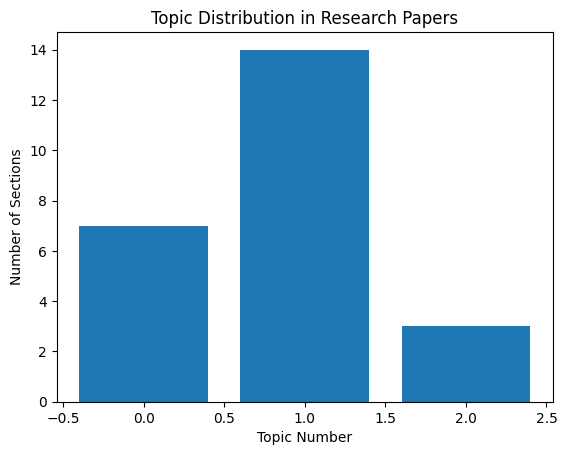

In [82]:
import matplotlib.pyplot as plt

topic_counts = df["Topic"].value_counts()

plt.bar(topic_counts.index, topic_counts.values)
plt.title("Topic Distribution in Research Papers")
plt.xlabel("Topic Number")
plt.ylabel("Number of Sections")
plt.show()

In [83]:
from transformers import pipeline

summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

print("Summarizer Loaded")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  36%|###6      | 587M/1.63G [00:00<?, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--facebook--bart-large-cnn. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Summarizer Loaded


In [84]:
text = df["Content"].iloc[0]

summary = summarizer(text[:3000], max_length=150, min_length=50, do_sample=False)

print(summary[0]["summary_text"])

Your max_length is set to 150, but your input_length is only 14. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=7)


Deep Learning-Based Brain Tumor Detection Using MRI Images. Using MRI images to detect brain tumours. Brain tumours can be identified using a combination of MRI and other techniques. Brain tumors can also be detected using other methods such as PET and CT.


In [85]:
def summarize_text(text):

    summary = summarizer(text[:3000], max_length=120, min_length=40, do_sample=False)

    return summary[0]["summary_text"]

In [86]:
summarize_text(df["Content"].iloc[1])

Your max_length is set to 120, but your input_length is only 53. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=26)


'Brain tumor detection is one of the most important applications of deep learning in medical imaging. This study explores convolutional neural networks and transfer learning models for automatic brain tumor classification using MRI images. The proposed approach aims to improve diagnostic accuracy while reducing manual effort.'

In [1]:
!pip install langchain
!pip install langchain-community
!pip install langchain-huggingface
!pip install langchain-text-splitters
!pip install sentence-transformers
!pip install transformers
!pip install faiss-cpu
!pip install pypdf

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.4 MB 4.2 MB/s eta 0:00:01
   ----------------- ---------------------- 1.0/2.4 MB 3.1 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.4 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 3.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 3.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 4.8 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.6 MB/s  0:00:00

   ------ ---------------------------------  2/13 [greenlet]
   ------ ---------------------------------  2/13 [green

In [2]:
import langchain
import transformers
import faiss
import sentence_transformers

print("LangChain Installed Successfully")

ModuleNotFoundError: No module named 'langchain'

In [3]:
import sys
print(sys.executable)

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python313\python.exe


In [1]:
import sys

print(sys.version)
print(sys.executable)

3.10.7 (tags/v3.10.7:6cc6b13, Sep  5 2022, 14:08:36) [MSC v.1933 64 bit (AMD64)]
C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import langchain
import transformers
import sentence_transformers
import faiss

print("Everything is working!")
print("LangChain:", langchain.__version__)

Everything is working!
LangChain: 1.3.13


In [3]:
import pandas as pd

from langchain_community.document_loaders import CSVLoader
from langchain_core.documents import Document

C:\Users\NAINA GAUR\AppData\Local\Temp\ipykernel_5584\273432065.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import CSVLoader


In [4]:
from langchain_core.documents import Document

In [5]:
documents = []

for _, row in df.iterrows():

    doc = Document(
        page_content=row["processed_text"],
        metadata={
            "Section_ID": row["Section_ID"],
            "Section_Title": row["Section_Title"]
        }
    )

    documents.append(doc)

NameError: name 'df' is not defined

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("processed_research_paper.csv")

In [8]:
df.head()

,Section_ID,Section_Title,Content,text,clean_text,tokens,processed_text,word_count
0,1,Title,Deep Learning-Based Brain Tumor Detection Usin...,Title. Deep Learning-Based Brain Tumor Detecti...,Title Deep LearningBased Brain Tumor Detection...,"['Title', 'Deep', 'LearningBased', 'Brain', 'T...",Title Deep LearningBased Brain Tumor Detection...,9
1,2,Abstract,Brain tumor detection is one of the most impor...,Abstract. Brain tumor detection is one of the ...,Abstract Brain tumor detection is one of the m...,"['Abstract', 'Brain', 'tumor', 'detection', 'o...",Abstract Brain tumor detection one important a...,37
2,3,Keywords,"Brain Tumor, Deep Learning, MRI, CNN, ResNet50...","Keywords. Brain Tumor, Deep Learning, MRI, CNN...",Keywords Brain Tumor Deep Learning MRI CNN Res...,"['Keywords', 'Brain', 'Tumor', 'Deep', 'Learni...",Keywords Brain Tumor Deep Learning MRI CNN Res...,13
3,4,Introduction,Brain tumors are abnormal growths of cells ins...,Introduction. Brain tumors are abnormal growth...,Introduction Brain tumors are abnormal growths...,"['Introduction', 'Brain', 'tumor', 'abnormal',...",Introduction Brain tumor abnormal growth cell ...,36
4,5,Problem Statement,Traditional diagnosis relies heavily on radiol...,Problem Statement. Traditional diagnosis relie...,Problem Statement Traditional diagnosis relies...,"['Problem', 'Statement', 'Traditional', 'diagn...",Problem Statement Traditional diagnosis relies...,24


In [9]:
print(df.columns)

Index(['Section_ID', 'Section_Title', 'Content', 'text', 'clean_text',
       'tokens', 'processed_text', 'word_count'],
      dtype='object')


In [10]:
from langchain_core.documents import Document

In [11]:
documents = []

for _, row in df.iterrows():
    doc = Document(
        page_content=str(row["processed_text"]),
        metadata={
            "Section_ID": row["Section_ID"],
            "Section_Title": row["Section_Title"]
        }
    )
    documents.append(doc)

In [12]:
print("Total Documents:", len(documents))
documents[0]

Total Documents: 24


Document(metadata={'Section_ID': 1, 'Section_Title': 'Title'}, page_content='Title Deep LearningBased Brain Tumor Detection Using MRI Images')

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [14]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""]
)

In [15]:
chunks = text_splitter.split_documents(documents)

In [16]:
print("Total Chunks:", len(chunks))

Total Chunks: 24


In [17]:
chunks[0]

Document(metadata={'Section_ID': 1, 'Section_Title': 'Title'}, page_content='Title Deep LearningBased Brain Tumor Detection Using MRI Images')

In [18]:
from langchain_huggingface import HuggingFaceEmbeddings

In [19]:
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

In [20]:
test_embedding = embedding_model.embed_query(
    "Brain tumor detection using CNN"
)

In [21]:
print("Embedding Dimension:", len(test_embedding))

Embedding Dimension: 384


In [22]:
from langchain_community.vectorstores import FAISS

In [23]:
vector_db = FAISS.from_documents(
    documents=chunks,
    embedding=embedding_model
)

In [24]:
print("FAISS Vector Database Created Successfully!")

FAISS Vector Database Created Successfully!


In [25]:
vector_db.save_local("research_vector_db")

In [26]:
vector_db = FAISS.load_local(
    "research_vector_db",
    embedding_model,
    allow_dangerous_deserialization=True
)

In [27]:
retriever = vector_db.as_retriever(
    search_kwargs={"k": 3}
)

In [28]:
query = "How is CNN used for brain tumor detection?"

results = retriever.invoke(query)

for i, doc in enumerate(results, start=1):
    print("=" * 80)
    print(f"Result {i}")
    print(doc.metadata)
    print(doc.page_content[:500])

Result 1
{'Section_ID': 3, 'Section_Title': 'Keywords'}
Keywords Brain Tumor Deep Learning MRI CNN ResNet50 Medical Imaging Artificial Intelligence Classification
Result 2
{'Section_ID': 6, 'Section_Title': 'Objectives'}
Objectives The objective study develop CNNbased brain tumor detection model compare transfer learning model ResNet50 VGG16 evaluate classification performance
Result 3
{'Section_ID': 1, 'Section_Title': 'Title'}
Title Deep LearningBased Brain Tumor Detection Using MRI Images


In [29]:
from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline

In [30]:
generator = pipeline(
    task="text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=256,
    temperature=0.3
)

config.json: 0.00B [00:00, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fal

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [31]:
generator = pipeline(
    task="text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=256,
    temperature=0.3
)

Device set to use cpu
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [32]:
llm = HuggingFacePipeline(
    pipeline=generator
)

In [33]:
response = llm.invoke(
    "Explain CNN in simple words."
)

print(response)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


CNN is a non-profit news organization based in Washington, D.C.


In [36]:
from langchain_core.prompts import ChatPromptTemplate

In [37]:
prompt = ChatPromptTemplate.from_template("""
You are an AI Research Assistant.

Use the following research paper context to answer the question.

Context:
{context}

Question:
{question}

Answer:
""")

In [38]:
question = "Explain CNN architecture used for brain tumor detection."

docs = retriever.invoke(question)

context = "\n\n".join([doc.page_content for doc in docs])

In [39]:
response = llm.invoke(
    prompt.format(
        context=context,
        question=question
    )
)

print(response)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


CNN ResNet50


In [40]:
!pip install -U langgraph langchain-core langchain-community langchain-huggingface

In [41]:
google/flan-t5-large

NameError: name 'google' is not defined

In [42]:
from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline

generator = pipeline(
    task="text2text-generation",
    model="google/flan-t5-large",
    max_new_tokens=256
)

llm = HuggingFacePipeline(
    pipeline=generator
)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

C:\Users\NAINA GAUR\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\NAINA GAUR\.cache\huggingface\hub\models--google--flan-t5-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fa

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [43]:
response = llm.invoke(
    "Explain CNN architecture used for brain tumor detection."
)

print(response)

CNN is a computer-based system for detecting brain tumors.


In [44]:
from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

Device set to use cpu


In [45]:
summary = summarizer(
    context,
    max_length=150,
    min_length=50,
    do_sample=False
)

print(summary[0]["summary_text"])

Your max_length is set to 150, but your input_length is only 75. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=37)


Study explores convolutional neural network transfer learning model automatic brain tumor classification using MRI image. The proposed approach aim improve diagnostic accuracy reducing manual effort. Study was published in the journal Brain Tumor and Tumors. For confidential support call the Samaritans on 08457 90 90 90 or visit a local Samaritans branch, see www.samaritans.org.


In [46]:
query = "MRI preprocessing"

results = retriever.invoke(query)

for doc in results:
    print(doc.metadata)
    print(doc.page_content[:500])

{'Section_ID': 14, 'Section_Title': 'MRI Dataset'}
MRI Dataset MRI image collected publicly available datasets Images resized normalized augmented model training
{'Section_ID': 15, 'Section_Title': 'Data Preprocessing'}
Data Preprocessing Image preprocessing includes resizing image normalization noise removal data augmentation using rotation flipping zooming
{'Section_ID': 21, 'Section_Title': 'Limitations'}
Limitations Model performance depends dataset quality quantity MRI image variation class imbalance may reduce prediction accuracy


In [47]:
from collections import Counter

In [48]:
all_words = []

for tokens in df["tokens"]:
    all_words.extend(tokens)

In [49]:
keyword_counts = Counter(all_words)

In [50]:
top_keywords = keyword_counts.most_common(20)

for word, count in top_keywords:
    print(f"{word}: {count}")

': 930
,: 441
 : 441
e: 375
i: 302
a: 281
n: 254
r: 218
t: 217
o: 204
l: 173
s: 165
c: 146
d: 118
m: 109
g: 96
u: 93
p: 84
f: 49
y: 46


In [51]:
section = "MRI Dataset"

In [52]:
result = df[df["Section_Title"].str.contains(section, case=False)]

result[["Section_Title", "Content"]]

,Section_Title,Content
13,MRI Dataset,MRI images are collected from publicly availab...


In [53]:
keyword = "CNN"

result = df[df["Content"].str.contains(keyword, case=False)]

result[["Section_Title", "Content"]]

,Section_Title,Content
2,Keywords,"Brain Tumor, Deep Learning, MRI, CNN, ResNet50..."
5,Objectives,The objectives of this study are to develop a ...
6,Literature Review,"Several studies have applied CNN, VGG16, ResNe..."
11,Convolutional Neural Network,CNN is specifically designed for image analysi...
15,Model Architecture,The proposed CNN model contains convolution la...
18,Results,The proposed CNN model achieves high classific...
22,Conclusion,Deep learning has significantly improved autom...


In [54]:
section1 = "Data Preprocessing"
section2 = "CNN Architecture"

text1 = df[df["Section_Title"] == section1]["Content"].values
text2 = df[df["Section_Title"] == section2]["Content"].values

print("Section 1")
print(text1)

print("\nSection 2")
print(text2)

Section 1
['Image preprocessing includes resizing images, normalization, noise removal, and data augmentation using rotation, flipping, and zooming.']

Section 2
[]


In [55]:
query = "Deep Learning"

results = retriever.invoke(query)

for i, doc in enumerate(results):
    print("="*80)
    print(doc.metadata)
    print(doc.page_content)

{'Section_ID': 24, 'Section_Title': 'References'}
References Goodfellow et al Deep Learning 2016 He et al Deep Residual Learning Image Recognition 2016 Simonyan Zisserman Very Deep Convolutional Networks 2015
{'Section_ID': 10, 'Section_Title': 'Deep Learning'}
Deep Learning Deep Learning branch machine learning us multiple neural network layer learn hierarchical representation data
{'Section_ID': 5, 'Section_Title': 'Problem Statement'}
Problem Statement Traditional diagnosis relies heavily radiologist making process timeconsuming prone human error An automated deep learning system assist doctor providing faster accurate prediction


In [56]:
questions = [
    "What is CNN?",
    "Explain MRI preprocessing.",
    "Which dataset is used?",
    "What are the limitations?"
]

for q in questions:

    docs = retriever.invoke(q)

    context = "\n\n".join([doc.page_content for doc in docs])

    response = llm.invoke(
        prompt.format(
            context=context,
            question=q
        )
    )

    print("="*80)
    print("Question:", q)
    print("Answer:", response)

Question: What is CNN?
Answer: Convolutional Neural Network
Question: Explain MRI preprocessing.
Answer: Image preprocessing includes resizing image normalization noise removal data augmentation using rotation flipping zooming
Question: Which dataset is used?
Answer: The dataset divided training validation testing set The Adam optimizer categorical crossentropy loss function used training Machine Learning Machine Learning subset Artificial Intelligence allows computer learn pattern data without explicit programming MRI Dataset MRI image collected publicly available datasets Images resized normalized augmented model training
Question: What are the limitations?
Answer: Model performance depends dataset quality quantity MRI image variation class imbalance may reduce prediction accuracy


In [57]:
summaries = []

for text in df["Content"]:

    summary = summarizer(
        text,
        max_length=100,
        min_length=30,
        do_sample=False
    )

    summaries.append(summary[0]["summary_text"])

Your max_length is set to 100, but your input_length is only 14. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=7)
Your max_length is set to 100, but your input_length is only 53. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=26)
Your max_length is set to 100, but your input_length is only 25. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=12)
Your max_length is set to 100, but your input_length is only 55. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=27)
Your 

In [58]:
df["Summary"] = summaries

In [59]:
df[["Section_Title", "Summary"]]

,Section_Title,Summary
0,Title,Deep Learning-Based Brain Tumor Detection Usin...
1,Abstract,Brain tumor detection is one of the most impor...
2,Keywords,Deep Learning can be used to learn more about ...
3,Introduction,Brain tumors are abnormal growths of cells ins...
4,Problem Statement,Traditional diagnosis relies heavily on radiol...
5,Objectives,The objectives of this study are to develop a ...
6,Literature Review,Transfer learning has significantly improved a...
7,Artificial Intelligence,Artificial Intelligence enables machines to si...
8,Machine Learning,Machine Learning is a subset of Artificial Int...
9,Deep Learning,Deep Learning is a branch of machine learning ...


In [60]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [61]:
class AgentState(TypedDict):
    question: str
    context: str
    answer: str

In [62]:
def retrieve(state: AgentState):

    docs = retriever.invoke(state["question"])

    context = "\n\n".join(
        [doc.page_content for doc in docs]
    )

    return {
        "context": context
    }

In [63]:
def generate(state: AgentState):

    prompt_text = f"""
You are an AI Research Assistant.

Use the research paper context below to answer the question.

Context:
{state["context"]}

Question:
{state["question"]}

Answer:
"""

    answer = llm.invoke(prompt_text)

    return {
        "answer": answer
    }

In [64]:
graph = StateGraph(AgentState)

graph.add_node("retrieve", retrieve)

graph.add_node("generate", generate)

graph.add_edge(START, "retrieve")

graph.add_edge("retrieve", "generate")

graph.add_edge("generate", END)

In [65]:
agent = graph.compile()

In [66]:
response = agent.invoke(
    {
        "question": "Explain CNN architecture used for brain tumor detection."
    }
)

print(response["answer"])

This study explores convolutional neural network transfer learning model automatic brain tumor classification using MRI image The proposed approach aim improve diagnostic accuracy reducing manual effort


In [67]:
def search_paper(question):

    docs = retriever.invoke(question)

    return "\n\n".join([doc.page_content for doc in docs])

In [68]:
def summarize_text(text):

    summary = summarizer(
        text,
        max_length=120,
        min_length=40,
        do_sample=False
    )

    return summary[0]["summary_text"]

In [69]:
def answer_question(question):

    docs = retriever.invoke(question)

    context = "\n\n".join(
        [doc.page_content for doc in docs]
    )

    prompt_text = f"""
Context:
{context}

Question:
{question}

Answer:
"""

    return llm.invoke(prompt_text)

In [70]:
from collections import Counter

def extract_keywords():

    words = []

    for tokens in df["tokens"]:
        words.extend(tokens)

    counter = Counter(words)

    return counter.most_common(20)

In [71]:
def paper_statistics():

    print("Total Sections :", len(df))

    print("Total Chunks :", len(chunks))

    print("Embedding Dimension :", len(test_embedding))

    print("Vector Database Ready")

In [72]:
print(search_paper("MRI preprocessing"))

MRI Dataset MRI image collected publicly available datasets Images resized normalized augmented model training

Data Preprocessing Image preprocessing includes resizing image normalization noise removal data augmentation using rotation flipping zooming

Limitations Model performance depends dataset quality quantity MRI image variation class imbalance may reduce prediction accuracy


In [73]:
print(answer_question("Explain CNN architecture"))

The proposed CNN model contains convolution layer followed ReLU activation max pooling dropout layer flattening dense layer softmax output layer Convolutional Neural Network CNN specifically designed image analysis It consists convolution layer pooling layer activation function fully connected layer Deep Learning Deep Learning branch machine learning us multiple neural network layer learn hierarchical representation data


In [74]:
print(extract_keywords())

[("'", 930), (',', 441), (' ', 441), ('e', 375), ('i', 302), ('a', 281), ('n', 254), ('r', 218), ('t', 217), ('o', 204), ('l', 173), ('s', 165), ('c', 146), ('d', 118), ('m', 109), ('g', 96), ('u', 93), ('p', 84), ('f', 49), ('y', 46)]


In [75]:
while True:

    question = input("Ask a question (type 'exit' to quit): ")

    if question.lower() == "exit":
        break

    answer = answer_question(question)

    print("\nAI Agent:\n")
    print(answer)
    print("-" * 80)

Ask a question (type 'exit' to quit):  what dataset is used



AI Agent:

MRI Dataset MRI image collected publicly available datasets Images resized normalized augmented model training Training Process The dataset divided training validation testing set The Adam optimizer categorical crossentropy loss function used training
--------------------------------------------------------------------------------


Ask a question (type 'exit' to quit):  exit


In [76]:
vector_db.save_local("brain_tumor_vector_db")

In [77]:
from langchain_core.tools import tool

In [78]:
@tool
def search_research_paper(question: str) -> str:
    """
    Search the research paper for relevant information.
    """

    docs = retriever.invoke(question)

    return "\n\n".join(
        [doc.page_content for doc in docs]
    )

In [79]:
@tool
def summarize_research_paper(text: str) -> str:
    """
    Summarize the given research paper text.
    """

    summary = summarizer(
        text,
        max_length=120,
        min_length=40,
        do_sample=False
    )

    return summary[0]["summary_text"]

In [80]:
@tool
def answer_from_paper(question: str) -> str:
    """
    Answer questions using the research paper.
    """

    docs = retriever.invoke(question)

    context = "\n\n".join(
        [doc.page_content for doc in docs]
    )

    prompt_text = f"""
You are an AI Research Assistant.

Context:
{context}

Question:
{question}

Answer:
"""

    return llm.invoke(prompt_text)

In [81]:
@tool
def extract_paper_keywords(dummy: str = "") -> str:
    """
    Extract the top keywords from the research paper.
    """

    from collections import Counter

    words = []

    for tokens in df["tokens"]:
        words.extend(tokens)

    counter = Counter(words)

    keywords = counter.most_common(20)

    return "\n".join(
        [f"{word}: {count}" for word, count in keywords]
    )

In [82]:
tools = [
    search_research_paper,
    summarize_research_paper,
    answer_from_paper,
    extract_paper_keywords
]

In [83]:
for tool in tools:
    print(tool.name)

search_research_paper
summarize_research_paper
answer_from_paper
extract_paper_keywords


In [84]:
from langgraph.prebuilt import create_react_agent

In [85]:
agent = create_react_agent(
    model=llm,
    tools=tools
)

C:\Users\NAINA GAUR\AppData\Local\Temp\ipykernel_5584\1123741138.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


AttributeError: 'HuggingFacePipeline' object has no attribute 'bind_tools'

In [86]:
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Search the paper for CNN architecture."
            }
        ]
    }
)

print(response)

KeyError: 'question'

In [87]:
from langchain.agents import create_agent

In [88]:
def detect_intent(user_input):

    user_input = user_input.lower()

    if "summarize" in user_input or "summary" in user_input:
        return "summarize"

    elif "keyword" in user_input or "keywords" in user_input:
        return "keywords"

    elif "search" in user_input or "find" in user_input:
        return "search"

    else:
        return "qa"

In [89]:
questions = [
    "Search CNN architecture",
    "Summarize MRI dataset",
    "Extract keywords",
    "Explain CNN"
]

for q in questions:
    print(q, "---->", detect_intent(q))

Search CNN architecture ----> search
Summarize MRI dataset ----> summarize
Extract keywords ----> keywords
Explain CNN ----> qa


In [90]:
def research_agent(question):

    intent = detect_intent(question)

    print("Selected Tool:", intent)

    if intent == "search":

        return search_research_paper.invoke(
            {"question": question}
        )

    elif intent == "summarize":

        docs = retriever.invoke(question)

        text = "\n".join(
            [doc.page_content for doc in docs]
        )

        return summarize_research_paper.invoke(
            {"text": text}
        )

    elif intent == "keywords":

        return extract_paper_keywords.invoke(
            {}
        )

    else:

        return answer_from_paper.invoke(
            {"question": question}
        )

In [91]:
print(
    research_agent(
        "Search MRI preprocessing"
    )
)

Selected Tool: search
MRI Dataset MRI image collected publicly available datasets Images resized normalized augmented model training

Data Preprocessing Image preprocessing includes resizing image normalization noise removal data augmentation using rotation flipping zooming

Keywords Brain Tumor Deep Learning MRI CNN ResNet50 Medical Imaging Artificial Intelligence Classification


In [92]:
print(
    research_agent(
        "Explain CNN architecture"
    )
)

Selected Tool: qa
The proposed CNN model contains convolution layer followed ReLU activation max pooling dropout layer flattening dense layer softmax output layer Convolutional Neural Network CNN specifically designed image analysis It consists convolution layer pooling layer activation function fully connected layer Deep Learning Deep Learning branch machine learning us multiple neural network layer learn hierarchical representation data


In [93]:
print(
    research_agent(
        "Summarize MRI Dataset"
    )
)

Selected Tool: summarize


Your max_length is set to 120, but your input_length is only 50. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=25)


 MRI Dataset MRI image collected publicly available datasets. Images resized normalized augmented model training. Limitations Model performance depends dataset quality quantity. MRI image variation class imbalance may reduce prediction accuracy.


In [94]:
print(
    research_agent(
        "Extract keywords"
    )
)

Selected Tool: keywords
': 930
,: 441
 : 441
e: 375
i: 302
a: 281
n: 254
r: 218
t: 217
o: 204
l: 173
s: 165
c: 146
d: 118
m: 109
g: 96
u: 93
p: 84
f: 49
y: 46


In [95]:
chat_history = []

In [96]:
def save_chat(question, answer):

    chat_history.append({
        "question": question,
        "answer": answer
    })

In [97]:
def show_history():

    for i, chat in enumerate(chat_history, 1):

        print("=" * 70)
        print(f"Conversation {i}")
        print("Question:", chat["question"])
        print("Answer:", chat["answer"])

In [98]:
def research_agent(question):

    intent = detect_intent(question)

    print("Selected Tool:", intent)

    if intent == "search":

        answer = search_research_paper.invoke(
            {"question": question}
        )

    elif intent == "summarize":

        docs = retriever.invoke(question)

        text = "\n".join(
            [doc.page_content for doc in docs]
        )

        answer = summarize_research_paper.invoke(
            {"text": text}
        )

    elif intent == "keywords":

        answer = extract_paper_keywords.invoke({})

    else:

        answer = answer_from_paper.invoke(
            {"question": question}
        )

    save_chat(question, answer)

    return answer

In [99]:
research_agent("Explain CNN")

Selected Tool: qa


'The proposed CNN model contains convolution layer followed ReLU activation max pooling dropout layer flattening dense layer softmax output layer Convolutional Neural Network CNN specifically designed image analysis It consists convolution layer pooling layer activation function fully connected layer'

In [100]:
research_agent("Summarize MRI Dataset")

Selected Tool: summarize


Your max_length is set to 120, but your input_length is only 50. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=25)


' MRI Dataset MRI image collected publicly available datasets. Images resized normalized augmented model training. Limitations Model performance depends dataset quality quantity. MRI image variation class imbalance may reduce prediction accuracy.'

In [101]:
research_agent("Extract keywords")

Selected Tool: keywords


"': 930\n,: 441\n : 441\ne: 375\ni: 302\na: 281\nn: 254\nr: 218\nt: 217\no: 204\nl: 173\ns: 165\nc: 146\nd: 118\nm: 109\ng: 96\nu: 93\np: 84\nf: 49\ny: 46"

In [102]:
show_history()

Conversation 1
Question: Explain CNN
Answer: The proposed CNN model contains convolution layer followed ReLU activation max pooling dropout layer flattening dense layer softmax output layer Convolutional Neural Network CNN specifically designed image analysis It consists convolution layer pooling layer activation function fully connected layer
Conversation 2
Question: Summarize MRI Dataset
Answer:  MRI Dataset MRI image collected publicly available datasets. Images resized normalized augmented model training. Limitations Model performance depends dataset quality quantity. MRI image variation class imbalance may reduce prediction accuracy.
Conversation 3
Question: Extract keywords
Answer: ': 930
,: 441
 : 441
e: 375
i: 302
a: 281
n: 254
r: 218
t: 217
o: 204
l: 173
s: 165
c: 146
d: 118
m: 109
g: 96
u: 93
p: 84
f: 49
y: 46


In [103]:
import os
import pandas as pd

In [104]:
folder_path = "papers"

In [105]:
all_data = []

for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        path = os.path.join(folder_path, file)

        temp_df = pd.read_csv(path)

        temp_df["paper_name"] = file

        all_data.append(temp_df)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'papers'

In [106]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current Folder:
C:\Users\NAINA GAUR

Files:
['.android', '.atom', '.bash_history', '.cache', '.codex', '.dotnet', '.eclipse', '.expo', '.git-for-windows-updater', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.node_repl_history', '.otk', '.p2', '.redhat', '.ssh', '.streamlit', '.templateengine', '.vscode', '.vscode-shared', 'aa', 'AI-Research-Paper-Intelligence-System', 'AI_Research_Agent.ipynb', 'apna college', 'AppData', 'Application Data', 'brain_tumor_research_paper.csv', 'brain_tumor_vector_db', 'Chess game', 'code', 'Contacts', 'Cookies', 'Customer-Churn-Prediction', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'Favorites', 'gg', 'GitPractise', 'hh', 'html', 'IdeaProjects', 'javascript', 'Links', 'Local Settings', 'main', 'Music', 'My Documents', 'my-app', 'NetHood', 'New folder (2)', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{0ce791c7-61e2-11f0-9db3-eb659238112f}.TxR.0.regtrans-ms', 'NTUSER.DA